<a href="https://colab.research.google.com/github/mkhabela-create/Big-Data-Midterm/blob/main/Sepsis_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step up and Introduction 

Sepsis is a leading cause of death in hospitals. Early prediction and diagnosis of sepsis, which is critical in reducing mortality, is challenging as many of its signs and symptoms are similar to other less critical conditions. As sepsis management is often based on a standardized management approach, early sepsis identification may be practically challenging and operational constraints in healthcare delivery can lead to unacceptably high mortality rates. It is a well-known fact that the diagnosis of sepsis is often equivocal due to the varied nature of infection sources and wide-ranging patients’ responses. 

Reference: https://www.nature.com/articles/s41467-021-20910-4

In [2]:
%pip install ydata-profiling imbalanced-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Update path to wherever train.csv lives
df = pd.read_csv('/content/train.csv')
df.shape

ModuleNotFoundError: No module named 'google'

In [4]:
# FOR SEKE - DON'T DELETE THIS CELL - JUST RUN IT TO LOAD THE DATA
################################
# Setup file path
file_location = r'/Users/sekemkhabela/Downloads/'
# Load datasets
df = pd.read_csv(file_location + 'train.csv')
df.shape

(1088197, 43)

# Cleaning and understanding the Data 

Understanding the data structure, variables, missing values etc. 

In [5]:
# Sort by patient and time to ensure correct fill direction
df = df.sort_values(['patient', 'time'])

# Forward fill within each patient's time series first,
# then backward fill to catch any gaps at the start of a patient's record
df = df.groupby('patient').apply(lambda g: g.ffill().bfill()).reset_index(drop=True)

# Confirm missingness reduction on raw data
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(10)

Bilirubin_direct    93.042344
EtCO2               89.602985
Fibrinogen          85.857616
TroponinI           81.943711
BaseExcess          63.739010
Lactate             63.352683
SaO2                62.791020
Alkalinephos        59.817110
Bilirubin_total     59.560723
AST                 59.361035
dtype: float64

In [6]:
# Define column groups
static_cols = ['patient', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

lab_cols = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
            'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
            'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
            'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
            'Fibrinogen', 'Platelets']

# Sepsis = 1 if patient was ever septic
sepsis = df.groupby('patient')['SepsisLabel'].max().reset_index()
sepsis.columns = ['patient', 'Sepsis']

# Vitals: mean across all timesteps
vitals_agg = df.groupby('patient')[vital_cols].mean().reset_index()
vitals_agg.columns = ['patient'] + [f'{c}_mean' for c in vital_cols]

# Labs: mean across timesteps — benefits from forward/backward fill above
labs_agg = df.groupby('patient')[lab_cols].mean().reset_index()
labs_agg.columns = ['patient'] + [f'{c}_mean' for c in lab_cols]

# Peak severity indicators
peak_agg = df.groupby('patient')[['Lactate', 'HR', 'Resp']].max().reset_index()
peak_agg.columns = ['patient', 'Lactate_peak', 'HR_peak', 'Resp_peak']

# Static features: first row per patient
static_agg = df.groupby('patient')[['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']].first().reset_index()

# Merge everything together
df_agg = sepsis.merge(static_agg, on='patient')
df_agg = df_agg.merge(vitals_agg, on='patient')
df_agg = df_agg.merge(labs_agg, on='patient')
df_agg = df_agg.merge(peak_agg, on='patient')

# Check shape and class balance
df_agg.shape, df_agg['Sepsis'].value_counts()

((28235, 45),
 Sepsis
 0.0    26173
 1.0     2062
 Name: count, dtype: int64)

In [7]:
df['patient'].nunique()
# Aggregate count and original unique IDs match

28235

In [8]:
# Missingness % per column, sorted
missing = (df_agg.isnull().sum() / len(df_agg) * 100).sort_values(ascending=False)
missing[missing > 0]

Bilirubin_direct_mean    94.836196
EtCO2_mean               91.786789
Fibrinogen_mean          88.514255
TroponinI_mean           82.535860
Lactate_peak             68.889676
Lactate_mean             68.889676
SaO2_mean                67.419869
BaseExcess_mean          67.157783
Alkalinephos_mean        64.816717
Bilirubin_total_mean     64.551089
AST_mean                 64.352754
FiO2_mean                55.760581
PaCO2_mean               54.234107
pH_mean                  52.796175
HCO3_mean                50.037188
PTT_mean                 49.810519
Chloride_mean            47.069240
Unit2                    38.537276
Unit1                    38.537276
Phosphate_mean           29.629892
DBP_mean                 18.370816
Calcium_mean             13.037011
Magnesium_mean           12.140960
WBC_mean                  6.346733
Platelets_mean            6.205065
Hgb_mean                  5.907562
Hct_mean                  5.574641
Creatinine_mean           4.915885
BUN_mean            

## Limitations
Forward/backward fill was applied to the raw time series prior to aggregation.
However, missingness in the aggregated dataset remained unchanged for high-MNAR
features, as most patients had zero recorded values for these labs — leaving
nothing to fill from. Median imputation was applied to all remaining missing
values after aggregation

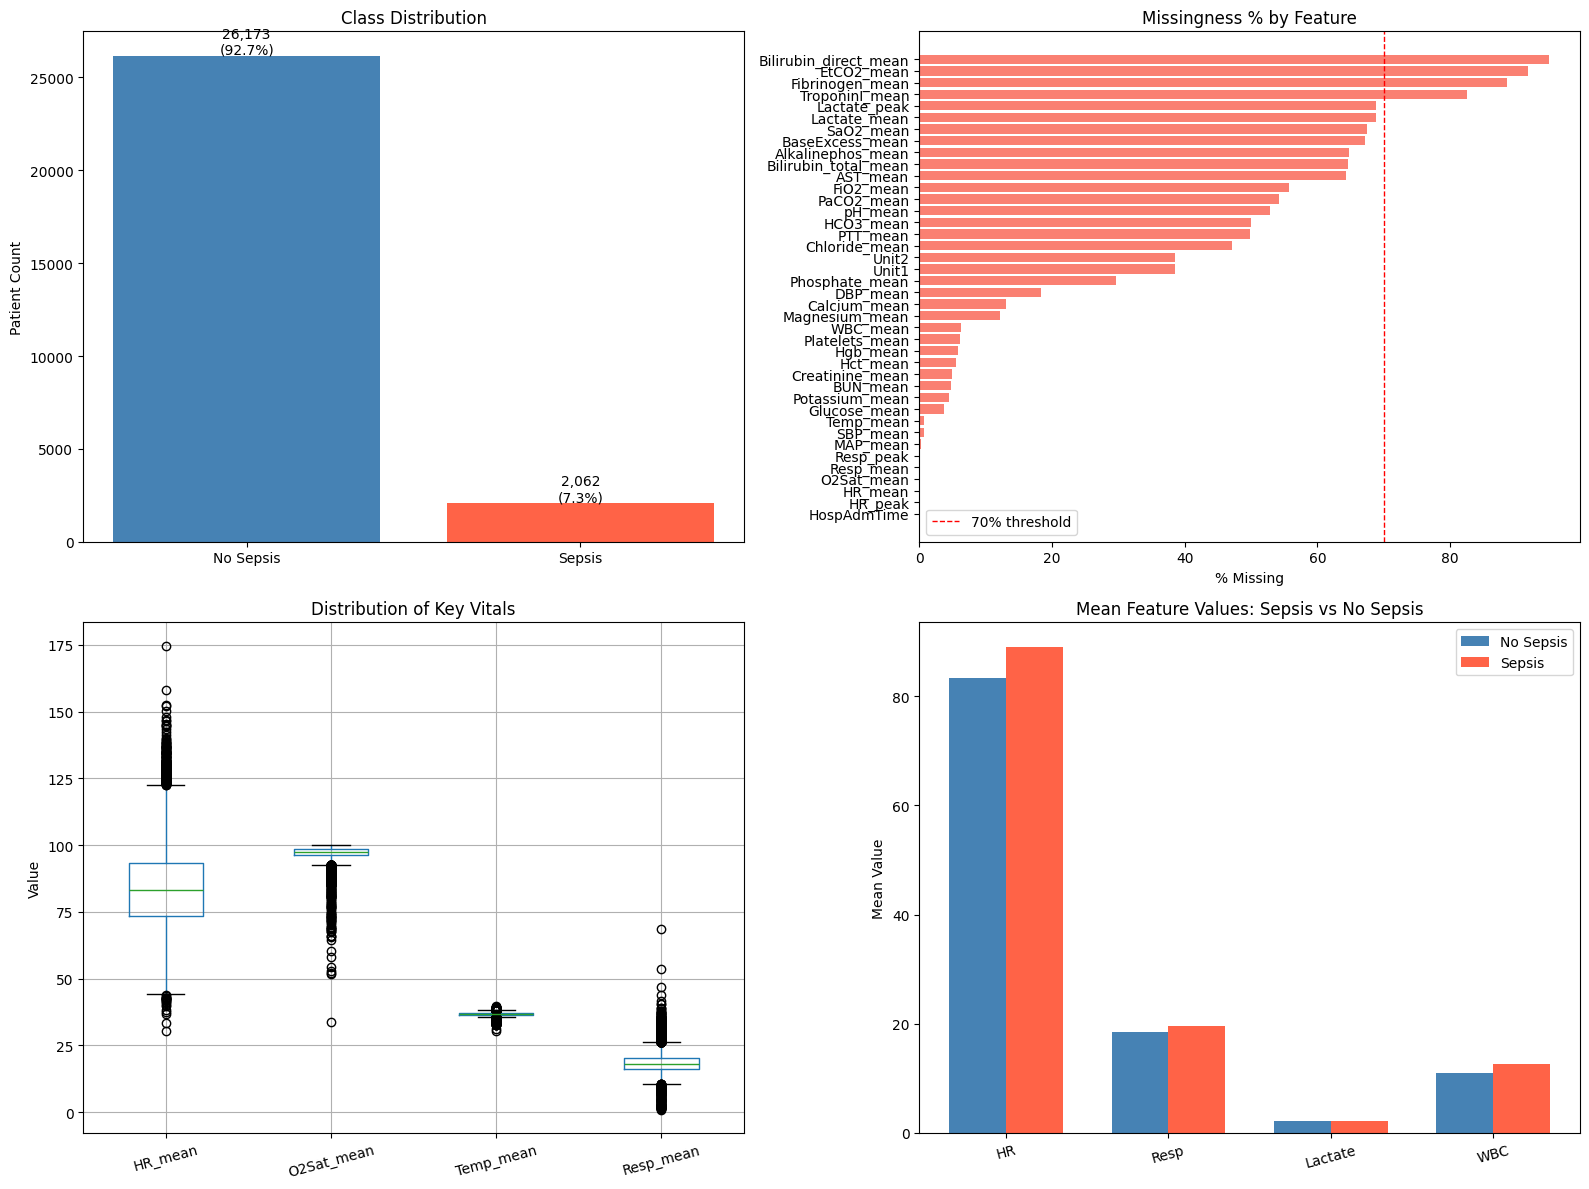

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class imbalance bar chart
ax = axes[0, 0]
counts = df_agg['Sepsis'].value_counts()
ax.bar(['No Sepsis', 'Sepsis'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(df_agg)*100:.1f}%)', ha='center')

# 2. Missingness heatmap
ax = axes[0, 1]
missing = (df_agg.isnull().sum() / len(df_agg) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
ax.barh(missing.index, missing.values, color='salmon')
ax.set_title('Missingness % by Feature')
ax.set_xlabel('% Missing')
ax.invert_yaxis()
ax.axvline(x=70, color='red', linestyle='--', linewidth=1, label='70% threshold')
ax.legend()

# 3. Key vitals distributions
ax = axes[1, 0]
vitals = ['HR_mean', 'O2Sat_mean', 'Temp_mean', 'Resp_mean']
df_agg[vitals].boxplot(ax=ax)
ax.set_title('Distribution of Key Vitals')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=15)

# 4. Sepsis vs non-sepsis — key features
ax = axes[1, 1]
sepsis_yes = df_agg[df_agg['Sepsis'] == 1]
sepsis_no = df_agg[df_agg['Sepsis'] == 0]
features = ['HR_mean', 'Resp_mean', 'Lactate_mean', 'WBC_mean']
means_yes = sepsis_yes[features].mean()
means_no = sepsis_no[features].mean()
x = np.arange(len(features))
width = 0.35
ax.bar(x - width/2, means_no.values, width, label='No Sepsis', color='steelblue')
ax.bar(x + width/2, means_yes.values, width, label='Sepsis', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['HR', 'Resp', 'Lactate', 'WBC'], rotation=15)
ax.set_title('Mean Feature Values: Sepsis vs No Sepsis')
ax.set_ylabel('Mean Value')
ax.legend()

plt.tight_layout()
plt.show()

## EDA Overview — Key Findings

**Class Imbalance**
The dataset is heavily imbalanced — 92.7% of patients (26,173) never developed
sepsis, with only 7.3% (2,062) classified as septic. This imbalance motivates the use of SMOTE during preprocessing and warrants
careful choice of evaluation metrics. Accuracy alone would be misleading
given that a model predicting no sepsis for every patient would still achieve
92.7% accuracy.

**Missingness**
Missingness varies dramatically across features. High-MNAR lab features
(Bilirubin_direct, EtCO2, Fibrinogen, TroponinI) exceed 80% missingness —
these are only ordered when clinically suspected, meaning their absence is
itself informative. Four features exceed the 70% threshold, and several
mid-range labs (Lactate, SaO2, BaseExcess) fall between 60-70%. Vitals
are near-complete at under 1% missing. All remaining missingness was
handled via median imputation after train/test splitting.

**Mean Feature Values: Sepsis vs No Sepsis**
Sepsis patients show notably higher mean HR compared to non-sepsis patients,
consistent with tachycardia as a primary sepsis indicator. Resp and WBC
are modestly elevated in sepsis patients. Lactate means are similar across
classes, though this is likely dampened by high missingness concentrating
observations toward lower baseline values.

**Distribution of Key Vitals**
HR shows the widest spread and most outliers of the four core vitals,
suggesting high variability across patients. O2Sat is tightly clustered
near 97-98% for most patients. Temp and Resp are relatively compact
distributions with few extreme outliers, indicating these vitals are
generally well-controlled in the ICU setting.

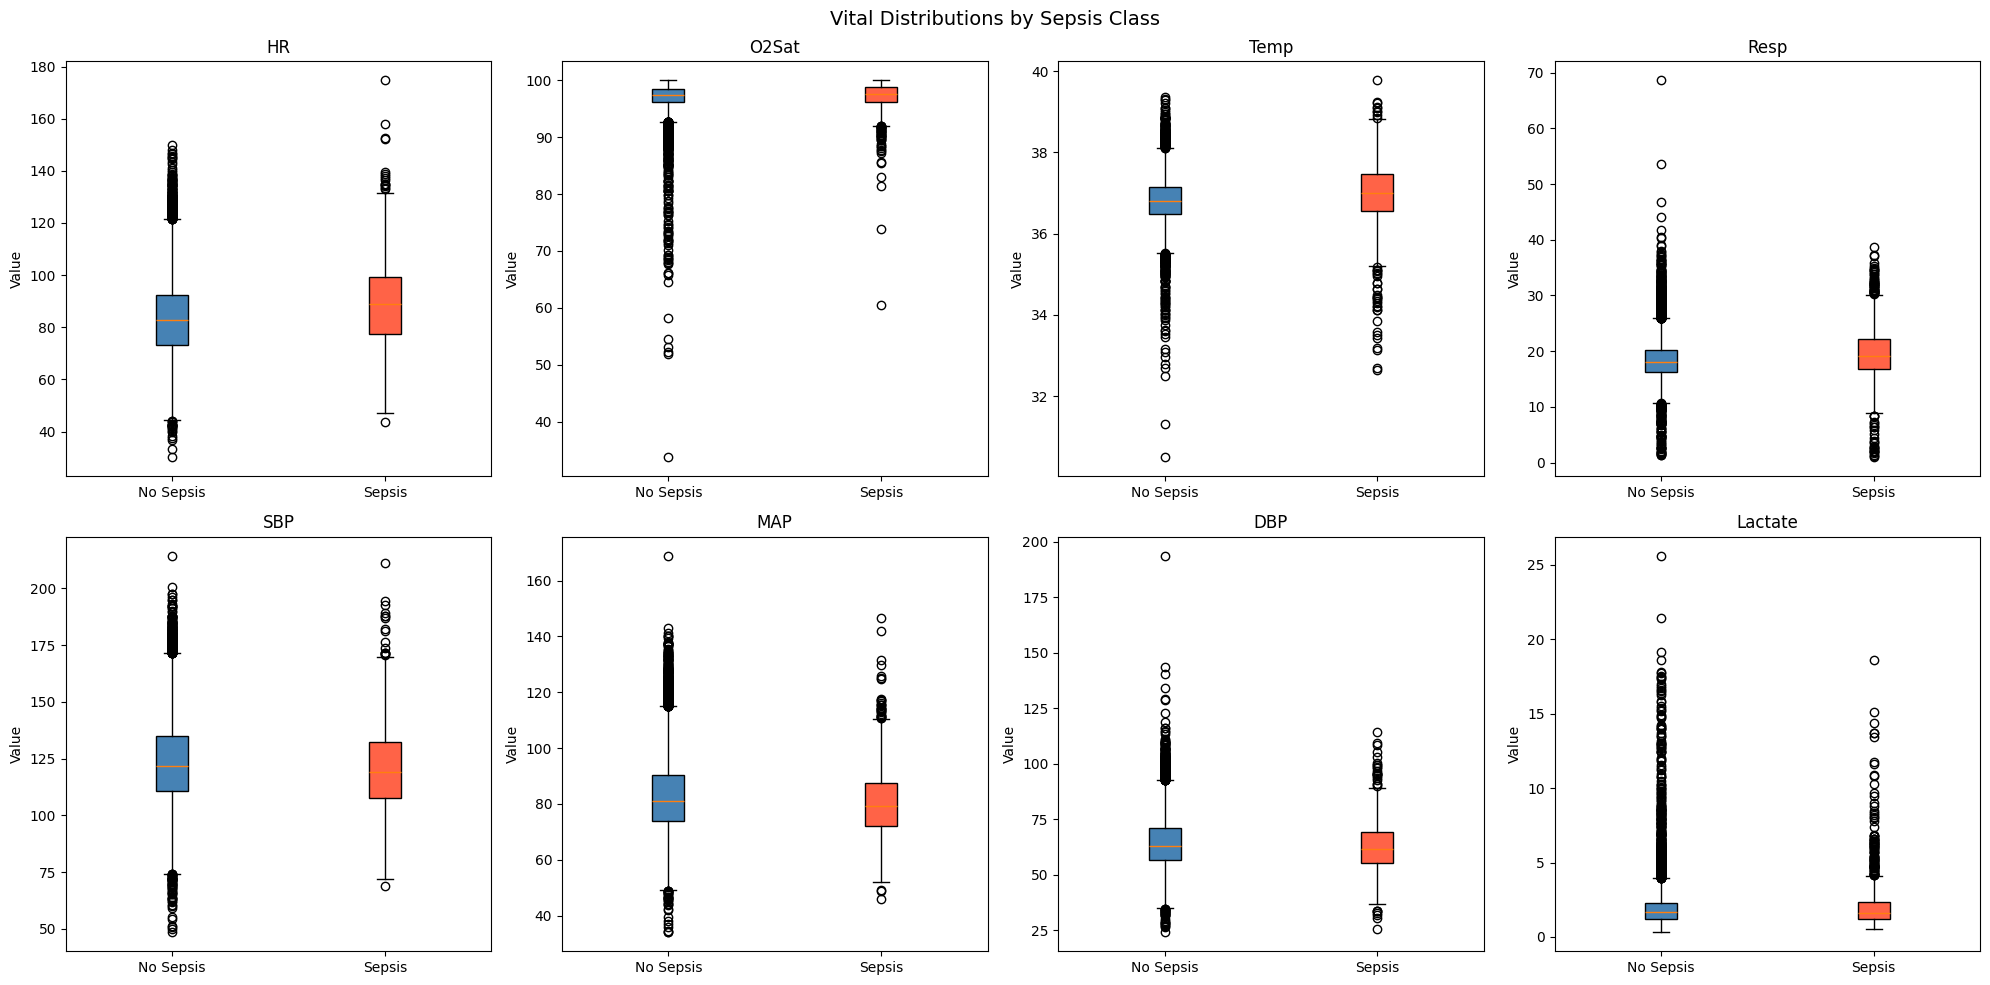

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

vitals = ['HR_mean', 'O2Sat_mean', 'Temp_mean', 'Resp_mean',
          'SBP_mean', 'MAP_mean', 'DBP_mean', 'Lactate_mean']

for ax, col in zip(axes.flatten(), vitals):
    data = [df_agg[df_agg['Sepsis'] == 0][col].dropna(),
            df_agg[df_agg['Sepsis'] == 1][col].dropna()]

    bp = ax.boxplot(data, labels=['No Sepsis', 'Sepsis'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(col.replace('_mean', ''))
    ax.set_ylabel('Value')

plt.suptitle('Vital Distributions by Sepsis Class', fontsize=14)
plt.tight_layout()
plt.show()

## Vital Distributions by Sepsis Class

Boxplots of key vital signs stratified by sepsis status reveal several
clinically meaningful patterns:

**HR (Heart Rate)** — sepsis patients exhibit a higher median heart rate
and wider spread, consistent with tachycardia as a hallmark sepsis symptom.

**Resp (Respiration Rate)** — a clear upward shift in median respiration
rate among sepsis patients, reflecting the increased respiratory demand
associated with systemic infection.

**Temp (Temperature)** — sepsis patients skew slightly higher, consistent
with fever as a common sepsis presentation, though class overlap is substantial.

**SBP, MAP, DBP (Blood Pressure)** — distributions are nearly identical
across classes, suggesting blood pressure measures alone are weak
discriminators for sepsis in this dataset.

**O2Sat (Oxygen Saturation)** — minimal difference between classes, with
both tightly clustered near 97-98%. Not expected to be a strong predictor.

**Lactate** — median values are similar across classes, but sepsis patients
show more extreme high-value outliers. Elevated lactate is a key clinical
marker of sepsis severity, though its signal here is concentrated in the tail
rather than the central distribution — likely a consequence of high missingness
(~69%) limiting the sample.

Overall, HR and Resp show the clearest distributional separation between
classes and are expected to be among the more important features during
classification.

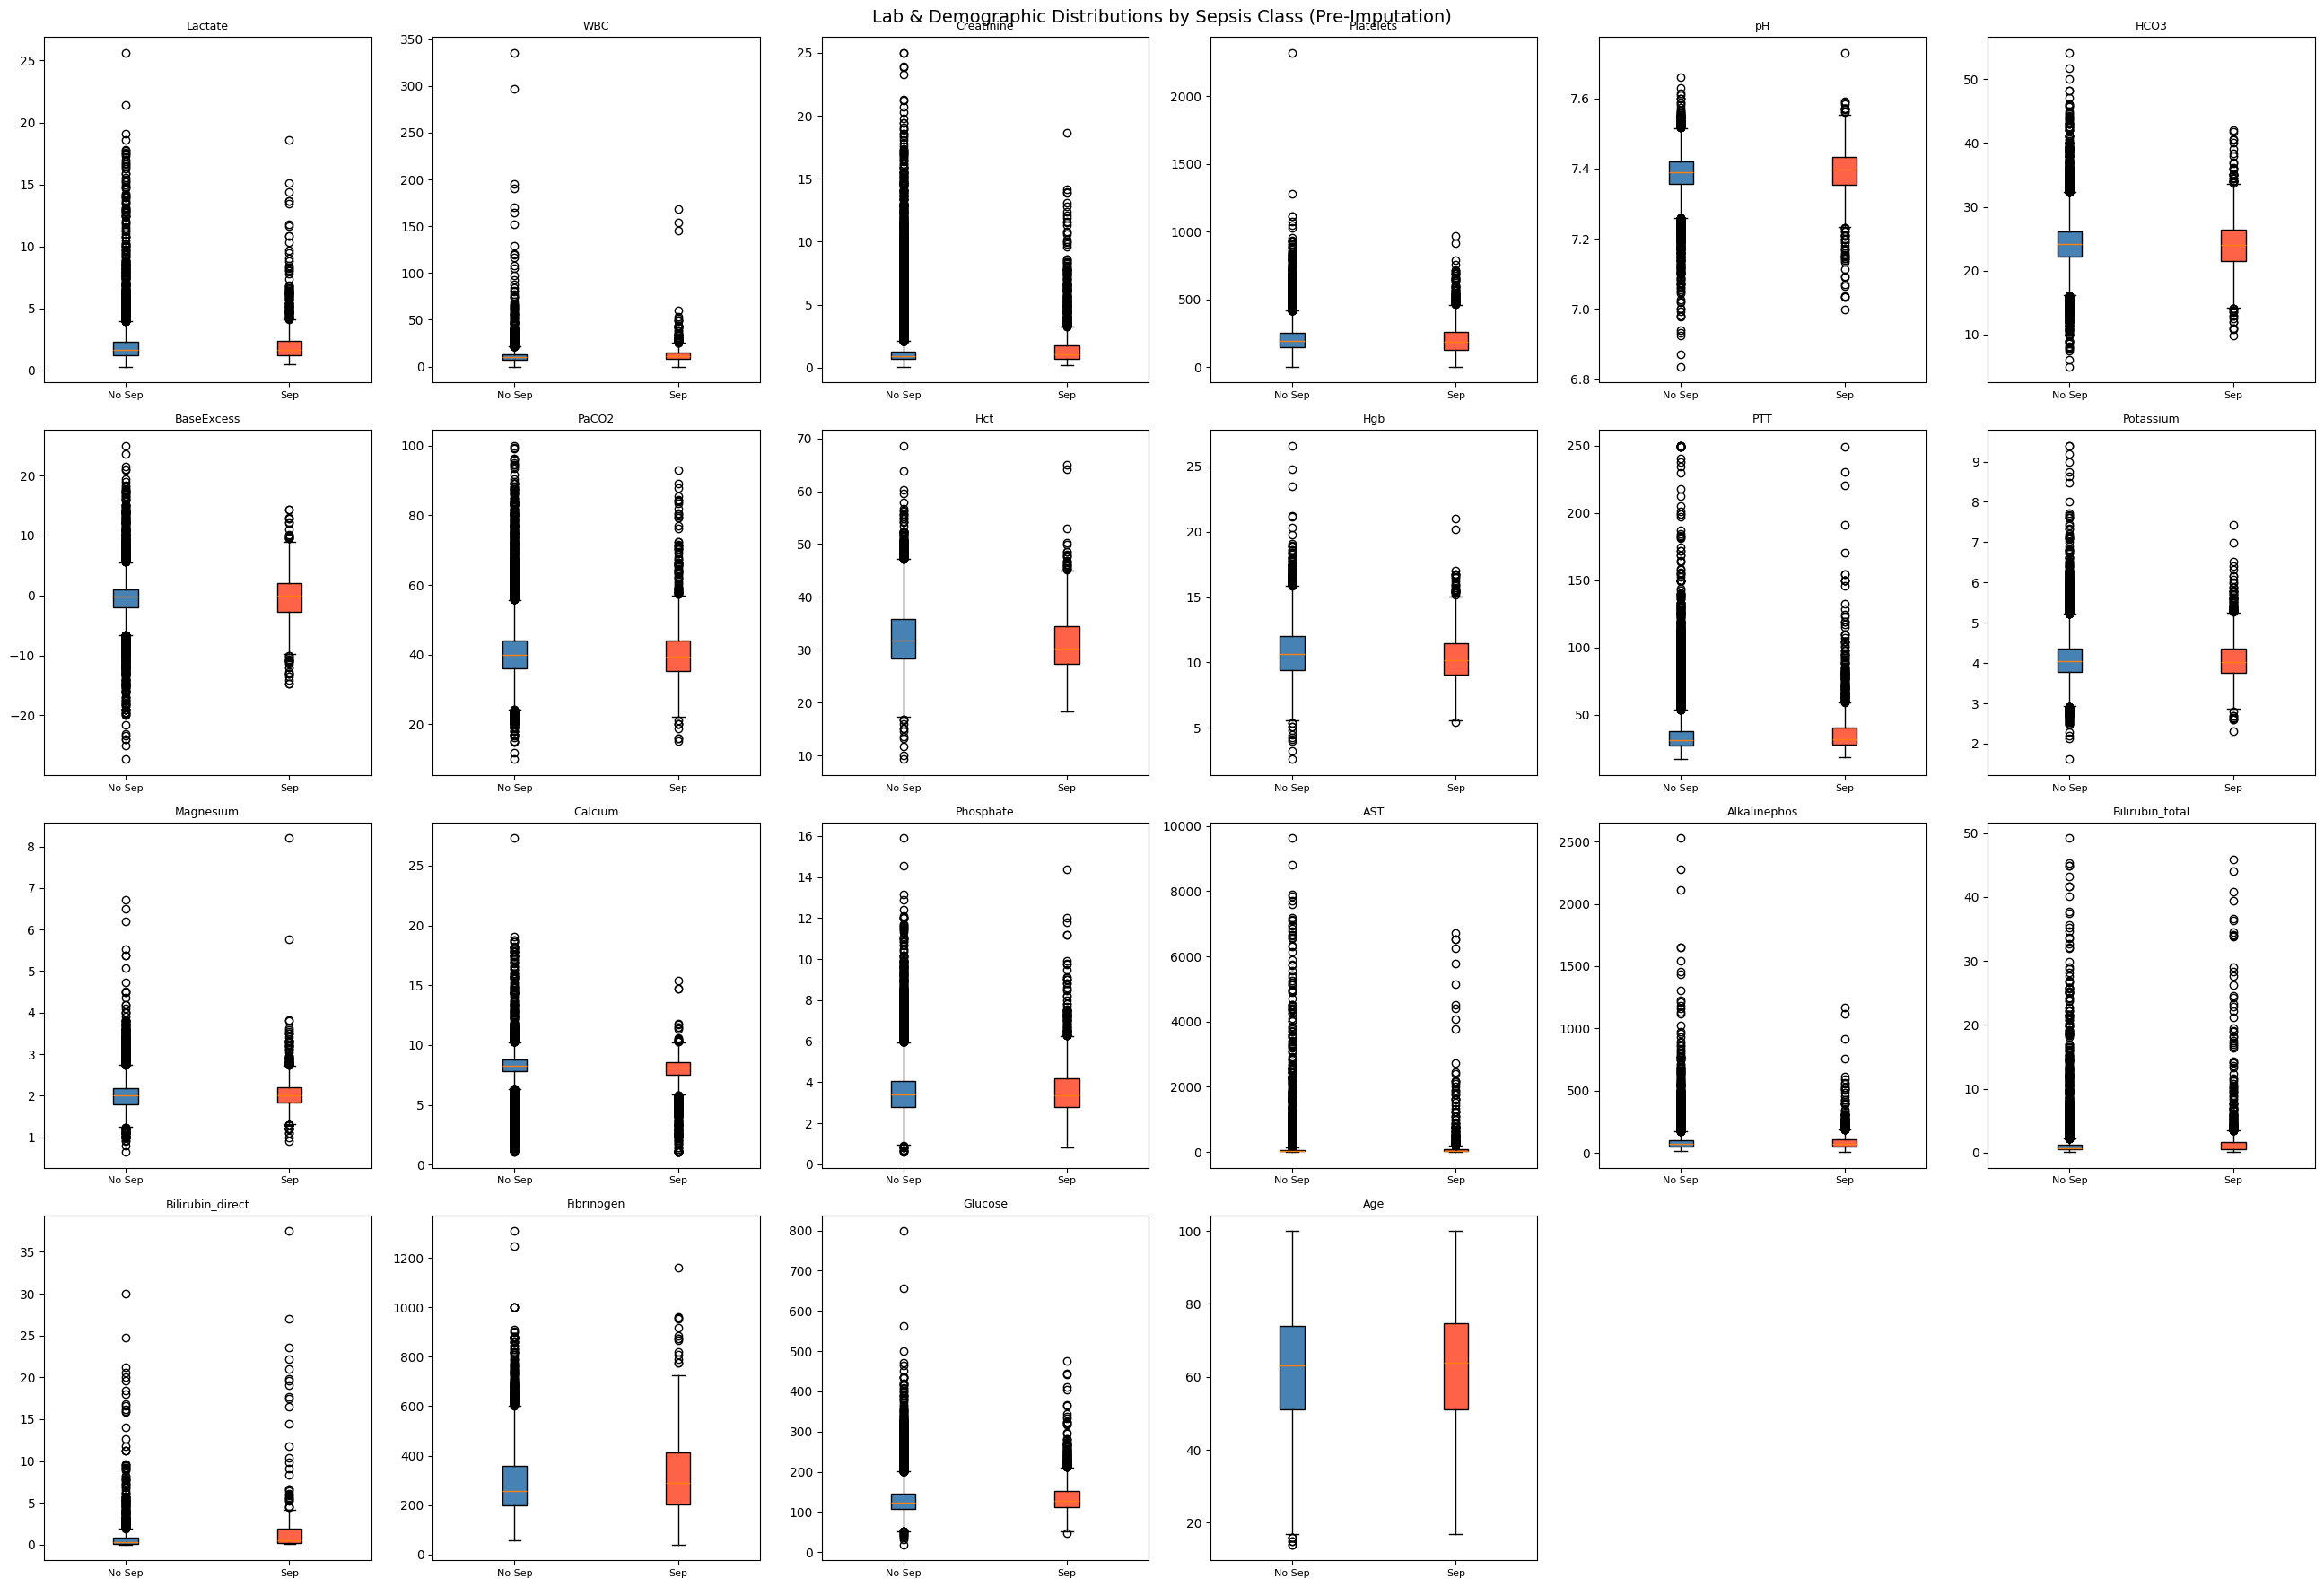

In [11]:
fig, axes = plt.subplots(4, 6, figsize=(26, 18))

features = [
    # Key sepsis labs
    'Lactate_mean', 'WBC_mean', 'Creatinine_mean', 'Platelets_mean',
    # Acid-base
    'pH_mean', 'HCO3_mean', 'BaseExcess_mean', 'PaCO2_mean',
    # Blood / coagulation
    'Hct_mean', 'Hgb_mean', 'PTT_mean',
    # Electrolytes
    'Potassium_mean', 'Magnesium_mean', 'Calcium_mean', 'Phosphate_mean',
    # Liver / organ dysfunction
    'AST_mean', 'Alkalinephos_mean', 'Bilirubin_total_mean', 'Bilirubin_direct_mean',
    # Other labs
    'Fibrinogen_mean', 'Glucose_mean',
    # Demographics
    'Age'
]

for ax, col in zip(axes.flatten(), features):
    data = [df_agg[df_agg['Sepsis'] == 0][col].dropna(),
            df_agg[df_agg['Sepsis'] == 1][col].dropna()]
    bp = ax.boxplot(data, labels=['No Sep', 'Sep'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(col.replace('_mean', ''), fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

# Hide unused axes
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.suptitle('Lab & Demographic Distributions by Sepsis Class (Pre-Imputation)', fontsize=14)
plt.tight_layout()
plt.show()

## Lab & Demographic Distributions by Sepsis Class

**Strong class separation — useful predictors:**

Lactate — sepsis patients show more high-value outliers, consistent with
tissue hypoperfusion. Signal concentrated in the tail due to ~69% missingness.

pH and BaseExcess — sepsis patients have notably lower median pH and more
negative BaseExcess, consistent with metabolic acidosis as a hallmark of
septic shock. These are among the clearest separating features in the dataset.

Phosphate — higher median in sepsis patients, consistent with kidney
dysfunction and impaired phosphate excretion.

Platelets — lower median in sepsis patients, consistent with
thrombocytopenia as a common sepsis complication and a component of
the SOFA severity score.

Fibrinogen — sepsis patients show a notably higher median, consistent
with fibrinogen being an acute phase protein that rises during infection.
Clinically meaningful despite high missingness (~88%).

Age — sepsis patients are older on average, confirming the well-established
clinical finding that older patients are significantly more susceptible
to sepsis.

**Moderate or ambiguous separation:**

Glucose — sepsis patients skew slightly higher, consistent with stress
hyperglycemia, though overlap between classes is substantial.

WBC — modest elevation in sepsis patients reflecting immune response,
though extreme outliers compress the visible distribution.

PTT — slight differences between classes, relevant as a coagulation
marker in severe sepsis and DIC, but overlap is high.

**Weak or no separation — limited predictive value:**

Hct and Hgb — nearly identical distributions across classes, confirming
these are weak individual predictors of sepsis. Their near-perfect
collinearity with each other also limits their combined contribution.

Magnesium and Calcium — very similar distributions across classes.
Electrolyte abnormalities in sepsis are non-specific and likely
secondary to other organ dysfunction.

AST, Alkalinephos, Bilirubin_direct, Bilirubin_total — extreme outliers
dominate the scale, making distributions difficult to interpret visually.
High missingness (>60%) further limits the signal available from these
liver dysfunction markers.

**Overall:** pH, BaseExcess, Platelets, Fibrinogen, and Age show the
clearest distributional separation between sepsis and non-sepsis patients.
Combined with HR and Resp from the vitals analysis, these features are
expected to contribute most during classification. Lasso regularization
will confirm which features survive formal feature selection.

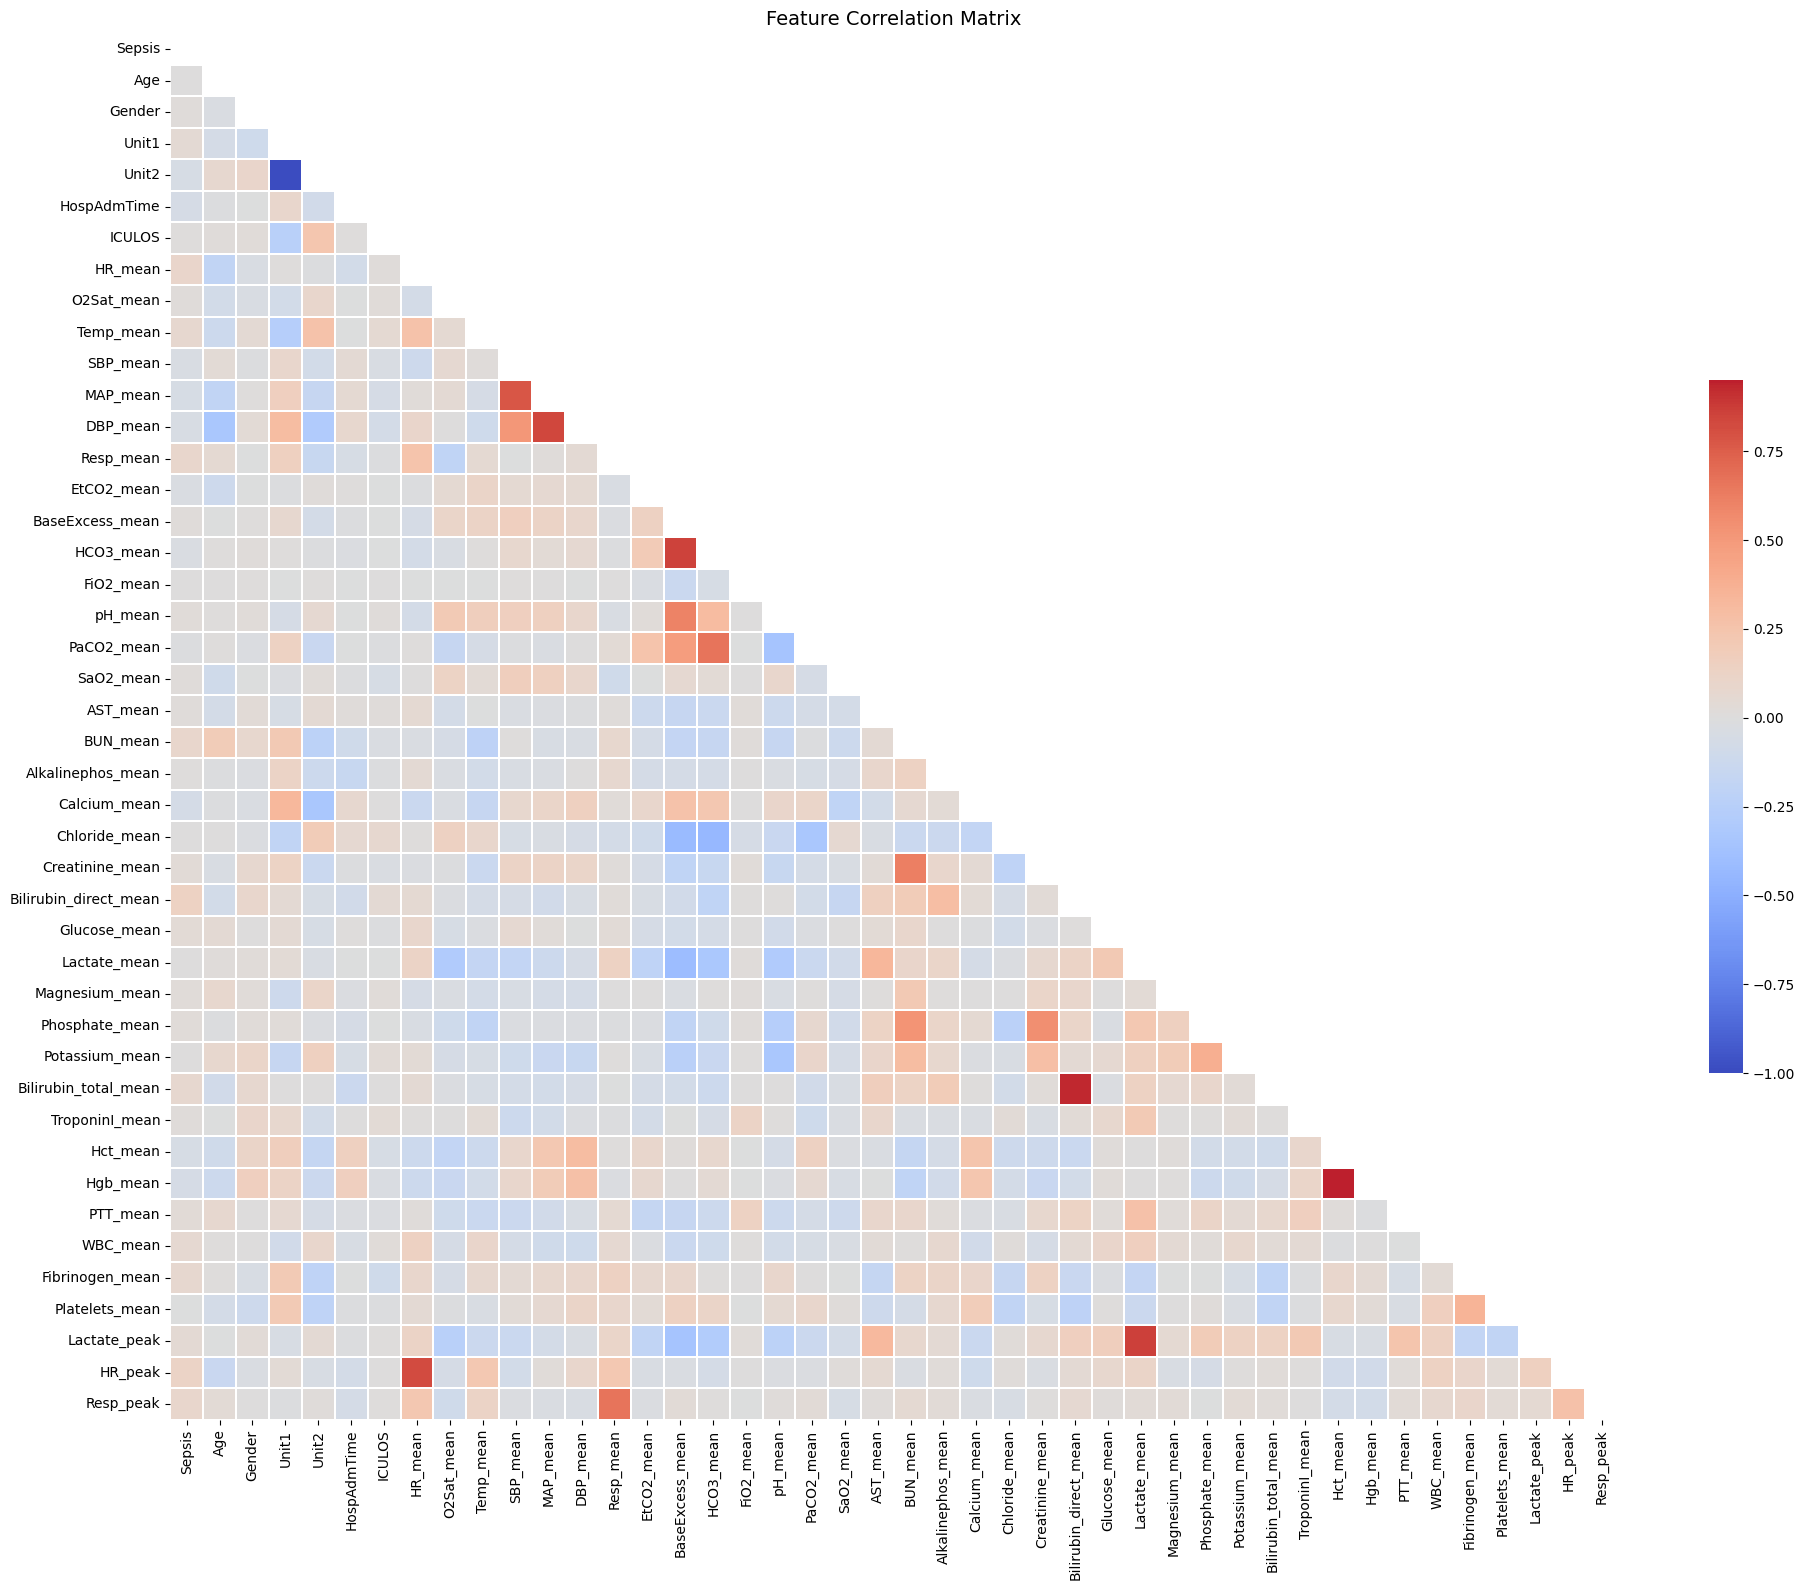

In [12]:
# Correlation heatmap (numeric features only, excluding patient ID)
fig, ax = plt.subplots(figsize=(20, 16))
corr = df_agg.drop(columns=['patient']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.5})
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## Multicollinearity Observations

From the correlation heatmap, most feature pairs show weak correlations,
suggesting the dataset does not suffer from severe multicollinearity overall.
However, several notable pairs warrant attention:

**Hct & Hgb** are the most strongly correlated pair in the matrix. Both measure
red blood cell concentration and are clinically redundant. Lasso regularization
will likely eliminate one during feature selection.

**Lactate_last & Lactate_peak** are highly correlated by construction since both
are derived from the same variable. Lactate_peak is retained as the preferred
feature given its clinical relevance as a severity indicator.

**SBP_mean, MAP_mean, DBP_mean** form a correlated cluster of blood pressure
measures. MAP is mathematically derived from SBP and DBP, making this
correlation expected. Lasso should reduce this cluster effectively.

**BaseExcess_last, HCO3_last, pH_last** are correlated acid-base markers,
standard in ICU data and clinically expected.

**BUN_last & Creatinine_last** show mild positive correlation as kidney
function markers, consistent with clinical expectations.

High-missingness labs (Bilirubin_direct, TroponinI, EtCO2) show weak
correlations throughout — these should be interpreted cautiously given
>80% missingness. These variables are likely MNAR: values are only ordered
when clinically suspected, meaning their absence is itself informative.

Additionally, engineered features representing different aggregations of the
same underlying variable (e.g. HR_mean and HR_peak) are correlated by
construction. Lasso regularization is the primary mechanism for resolving
this redundancy during feature selection.





In [13]:
# Define features and target — drop patient ID (not a feature) and target
X = df_agg.drop(columns=['patient', 'Sepsis'])
y = df_agg['Sepsis']

# Stratified 80/20 split on patient level — preserves ~7.3% sepsis rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True).round(3)

((22588, 43),
 (5647, 43),
 Sepsis
 0.0    0.927
 1.0    0.073
 Name: proportion, dtype: float64)

In [14]:
# Median imputation — fit on training set only, transform both
# Prevents any test set information leaking into the imputer
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Confirm no missing values remain
X_train_imp.isnull().sum().sum(), X_test_imp.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [15]:
# Fit scaler on training set only, transform both
# Critical for LDA, KNN, and regularized Logit — less so for Naive Bayes and QDA
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

# Confirm scaling worked — training set should have mean ~0 and std ~1
X_train_scaled.mean().round(2).head(), X_train_scaled.std().round(2).head()

(Age            0.0
 Gender         0.0
 Unit1         -0.0
 Unit2          0.0
 HospAdmTime   -0.0
 dtype: float64,
 Age            1.0
 Gender         1.0
 Unit1          1.0
 Unit2          1.0
 HospAdmTime    1.0
 dtype: float64)

In [16]:
# Apply SMOTE to training set only — never to test set
# Oversamples the minority class (Sepsis=1) to balance training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Confirm class balance after SMOTE
X_train_res.shape, pd.Series(y_train_res).value_counts()

((41876, 43),
 Sepsis
 0.0    20938
 1.0    20938
 Name: count, dtype: int64)

## SMOTE — Synthetic Minority Oversampling Technique

The training dataset is heavily imbalanced — approximately 92.7% of patients
never developed sepsis, with only 7.3% classified as septic. Training a
classifier on imbalanced data leads to biased predictions toward the majority
class, producing models that effectively ignore the minority class entirely.

SMOTE addresses this by synthetically generating new minority class observations.
Rather than simply duplicating existing sepsis cases, SMOTE creates new synthetic
patients by interpolating between existing sepsis patients and their nearest
neighbors in feature space. This produces plausible but novel examples that
help the classifier learn the boundaries of the sepsis class more effectively.

After applying SMOTE, the training set is balanced at 50/50 (20,938 sepsis
and 20,938 non-sepsis patients), giving classifiers equal exposure to both
classes during training. Importantly, SMOTE is applied to the training set
only — the test set retains the original class distribution to reflect
real-world conditions and ensure unbiased evaluation.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Lasso logistic regression — C is inverse of regularization strength
# Lower C = stronger regularization = more features zeroed out
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
lasso.fit(X_train_res, y_train_res)

# Get surviving features (non-zero coefficients)
feature_names = X_train_res.columns
lasso_coefs = pd.Series(lasso.coef_[0], index=feature_names)

# Show all coefficients sorted by absolute value
lasso_coefs_sorted = lasso_coefs.reindex(lasso_coefs.abs().sort_values(ascending=False).index)
lasso_coefs_sorted

Lactate_peak             3.794652e-01
HR_peak                  3.680076e-01
Hgb_mean                -3.158643e-01
Hct_mean                 3.089604e-01
BUN_mean                 3.043052e-01
Lactate_mean            -2.851293e-01
Temp_mean                2.472381e-01
O2Sat_mean               2.468572e-01
Potassium_mean          -2.055021e-01
Resp_mean                1.967129e-01
MAP_mean                -1.542796e-01
WBC_mean                 1.487224e-01
Gender                   1.474996e-01
ICULOS                  -1.338903e-01
PaCO2_mean               1.184072e-01
Glucose_mean             1.180857e-01
HCO3_mean               -1.125346e-01
BaseExcess_mean          1.074333e-01
FiO2_mean                1.036799e-01
Bilirubin_total_mean     9.138346e-02
pH_mean                  8.680417e-02
DBP_mean                -7.213546e-02
Age                      7.106821e-02
Calcium_mean            -6.297083e-02
Bilirubin_direct_mean    5.682796e-02
SBP_mean                -5.664032e-02
Fibrinogen_m

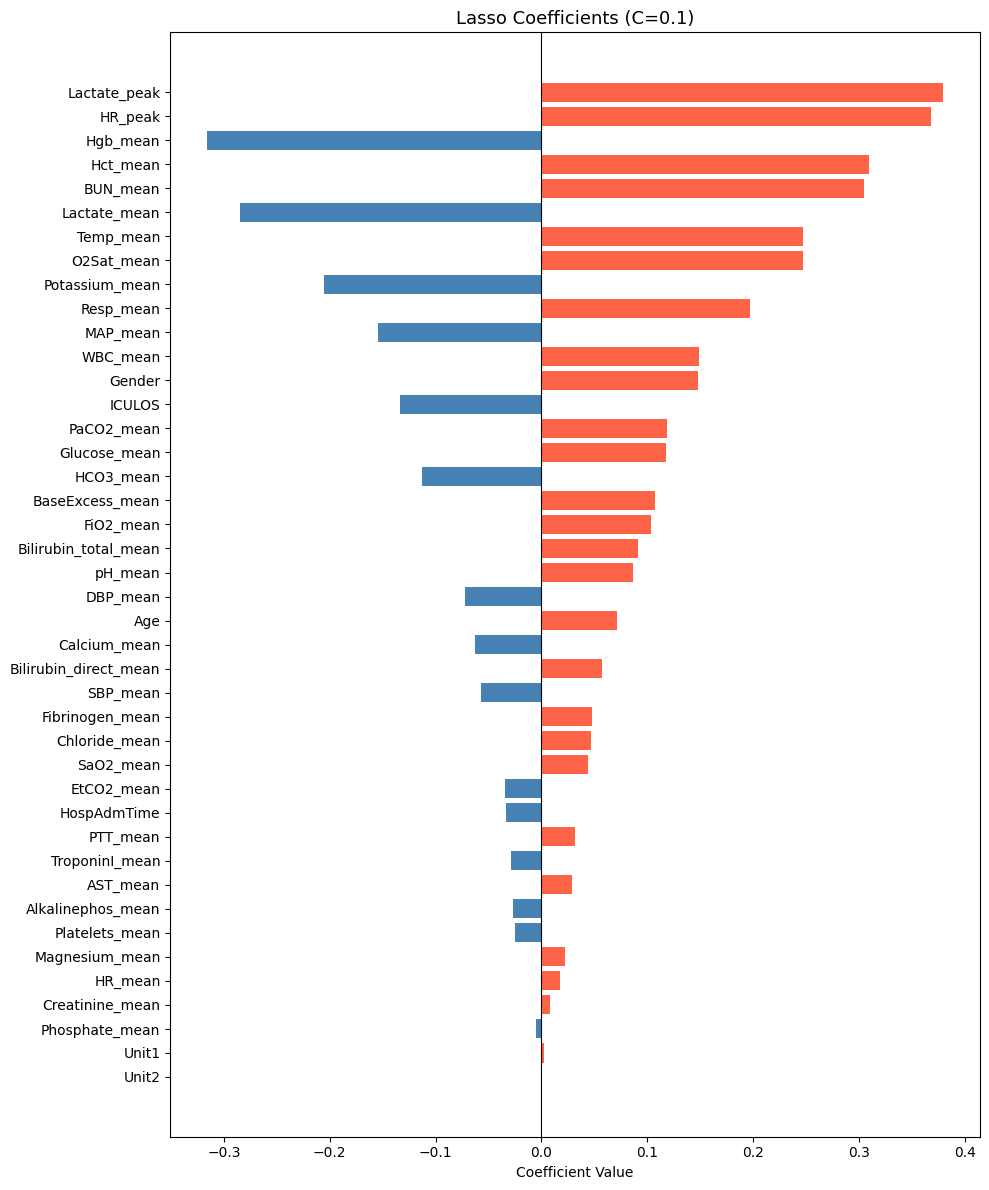

In [18]:
fig, ax = plt.subplots(figsize=(10, 12))

# Plot non-zero coefficients only
nonzero = lasso_coefs_sorted[lasso_coefs_sorted != 0]
colors = ['tomato' if c > 0 else 'steelblue' for c in nonzero.values]

ax.barh(nonzero.index, nonzero.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Lasso Coefficients (C=0.1)', fontsize=13)
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
# Generating the summary table for the clean data
print(X_train_res.columns)

import pandas as pd

# Define variable groups based on project instructions 
demographics = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
vitals = ['HR_mean', 'O2Sat_mean', 'Temp_mean', 'SBP_mean', 'MAP_mean', 
          'DBP_mean', 'Resp_mean', 'EtCO2_mean', 'HR_peak', 'Resp_peak']
labs = ['BaseExcess_mean', 'HCO3_mean', 'FiO2_mean', 'pH_mean', 'PaCO2_mean', 
        'SaO2_mean', 'AST_mean', 'BUN_mean', 'Alkalinephos_mean', 'Calcium_mean', 
        'Chloride_mean', 'Creatinine_mean', 'Bilirubin_direct_mean', 'Glucose_mean', 
        'Lactate_mean', 'Magnesium_mean', 'Phosphate_mean', 'Potassium_mean', 
        'Bilirubin_total_mean', 'TroponinI_mean', 'Hct_mean', 'Hgb_mean', 
        'PTT_mean', 'WBC_mean', 'Fibrinogen_mean', 'Platelets_mean', 'Lactate_peak']

# Select all features from your list
all_features = demographics + vitals + labs

# Create the summary statistics table 
summary_df = X_train_res[all_features].describe().T

# Map categories to the table for the report insights 
def get_category(col):
    if col in demographics: return 'Demographic'
    if col in vitals: return 'Vital Sign'
    return 'Laboratory Value'

summary_df['Category'] = summary_df.index.map(get_category)

# Final formatted table
summary_df = summary_df[['Category', 'mean', 'std', 'min', '50%', 'max']]
print(summary_df.sort_values(by='Category'))

Index(['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'HR_mean',
       'O2Sat_mean', 'Temp_mean', 'SBP_mean', 'MAP_mean', 'DBP_mean',
       'Resp_mean', 'EtCO2_mean', 'BaseExcess_mean', 'HCO3_mean', 'FiO2_mean',
       'pH_mean', 'PaCO2_mean', 'SaO2_mean', 'AST_mean', 'BUN_mean',
       'Alkalinephos_mean', 'Calcium_mean', 'Chloride_mean', 'Creatinine_mean',
       'Bilirubin_direct_mean', 'Glucose_mean', 'Lactate_mean',
       'Magnesium_mean', 'Phosphate_mean', 'Potassium_mean',
       'Bilirubin_total_mean', 'TroponinI_mean', 'Hct_mean', 'Hgb_mean',
       'PTT_mean', 'WBC_mean', 'Fibrinogen_mean', 'Platelets_mean',
       'Lactate_peak', 'HR_peak', 'Resp_peak'],
      dtype='object')
                               Category      mean       std         min  \
Age                         Demographic  0.025452  0.942951   -2.873679   
Gender                      Demographic  0.045093  0.955137   -1.132288   
Unit1                       Demographic  0.005698  0.984951   -

# Logit Regression 

This project specifically requires the use of Lasso (L1) or Ridge (L2) regularization to select features.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 'liblinear' is good for small datasets; 'saga' is better for large ones
# penalty='l1' implements Lasso for feature selection
logit_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

# Define a grid of C values (C is the inverse of regularization strength)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# 10-fold Cross-Validation as required by Step 2.1
grid_search = GridSearchCV(logit_model, param_grid, cv=10, scoring='f1')
grid_search.fit(X_train_res, y_train_res)

best_logit = grid_search.best_estimator_


In [33]:
import statsmodels.api as sm
# Statsmodels requires an explicit intercept (constant) term
X_train_const = sm.add_constant(X_train_res) 

# Fit the Logit model
logit_sm = sm.Logit(y_train_res, X_train_const).fit()

# Print the results summary
print(logit_sm.summary())

# Extracting specific metrics for report
print("\n--- Key Statistics for Report ---")
results_as_html = logit_sm.summary().tables[1].as_html()
df_results = pd.read_html(results_as_html, header=0, index_col=0)[0]

# Filter for statistically significant features (p < 0.05)
significant_features = df_results[df_results['P>|z|'] < 0.05]
print("Statistically Significant Predictors (p < 0.05):")
print(significant_features)

Optimization terminated successfully.
         Current function value: 0.613672
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Sepsis   No. Observations:                41876
Model:                          Logit   Df Residuals:                    41833
Method:                           MLE   Df Model:                           42
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.1147
Time:                        15:27:02   Log-Likelihood:                -25698.
converged:                       True   LL-Null:                       -29026.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.2856      0.011    -25.318      0.000      -0.308      -0.

In [34]:
# Extract coefficients and feature names
# best_logit is your trained LogisticRegression model from GridSearchCV
features = X_train_res.columns
coefficients = best_logit.coef_[0]

# Create a DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient (Log-Odds)': coefficients
})

# Calculate Odds Ratios: OR = exp(beta)
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient (Log-Odds)'])

# Calculate % Change in Odds: (OR - 1) * 100
coef_df['% Change in Odds'] = (coef_df['Odds Ratio'] - 1) * 100

# Sort by absolute impact (highest positive or negative coefficients)
coef_df['Abs_Coef'] = coef_df['Coefficient (Log-Odds)'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

# Display the top features for your report
print("Logit Model Coefficients and Interpretations:")
print(coef_df.head(10).to_string(index=False))

Logit Model Coefficients and Interpretations:
       Feature  Coefficient (Log-Odds)  Odds Ratio  % Change in Odds
  Lactate_peak                0.389047    1.475574         47.557443
       HR_peak                0.367650    1.444337         44.433688
      Hgb_mean               -0.348495    0.705749        -29.425087
      Hct_mean                0.343128    1.409348         40.934850
      BUN_mean                0.304675    1.356184         35.618394
  Lactate_mean               -0.294837    0.744653        -25.534678
    O2Sat_mean                0.250823    1.285083         28.508308
     Temp_mean                0.248873    1.282579         28.257899
Potassium_mean               -0.208539    0.811769        -18.823096
     Resp_mean                0.197460    1.218304         21.830398


## Top Positive Predictors (Increasing Risk)
These features have an Odds Ratio (OR) > 1, meaning as these values rise, the likelihood of a sepsis diagnosis increases.

- `Lactate_peak` (Odds Ratio : 1.476): This is the strongest predictor. For every one-unit increase in the peak lactate level, the odds of the patient having sepsis increase by approximately 47.5%. In a clinical context, high lactate often indicates organ hypoperfusion or tissue hypoxia, which are hallmarks of sepsis.
- `HR_peak` (Odds Ratio: 1.444): A one-unit increase in peak heart rate increases sepsis odds by 44.4%. This aligns with clinical expectations, as tachycardia (elevated heart rate) is a primary component of SIRS (Systemic Inflammatory Response Syndrome) criteria used to identify sepsis.
- `BUN_mean` (Odds Ratio: 1.356): Elevated Blood Urea Nitrogen levels increase odds by 35.6%. This likely reflects the impact of sepsis on renal (kidney) function.

## Top Negative Predictors
These features have an Odds Ratio < 1, meaning higher values are associated with a lower probability of sepsis in this specific model. 

- `Hgb_mean` (Odds Ratio: 0.706): Higher mean hemoglobin levels are associated with a 29.4% decrease in the odds of sepsis. This suggests that patients with healthier blood oxygen-carrying capacity in the dataset were less likely to be septic.
- `Lactate_mean` (Odds Ratio: 0.745): Interestingly, while peak lactate is a strong positive predictor, the mean lactate shows a negative coefficient (25.5% decrease in odds).

Since `Lactate_peak` and `Lactate_mean` are likely highly correlated, the model may be struggling to partition the variance between them. This often points to multicollinearity. Hemoglobin/Hematocrit (`Hgb_mean` vs. `Hct_mean`) are having the same issue. 



## Logit Precision Testing  

--- Logistic Regression Coefficients ---
                  Feature  Coefficient
41           Lactate_peak     0.389938
42                HR_peak     0.367605
35               Hct_mean     0.347146
22               BUN_mean     0.304659
8              O2Sat_mean     0.251193
9               Temp_mean     0.249046
13              Resp_mean     0.197754
38               WBC_mean     0.151946
2                  Gender     0.150620
19             PaCO2_mean     0.121001
28           Glucose_mean     0.120571
15        BaseExcess_mean     0.109617
17              FiO2_mean     0.108657
33   Bilirubin_total_mean     0.092840
18                pH_mean     0.089298
1                     Age     0.072216
27  Bilirubin_direct_mean     0.057695
39        Fibrinogen_mean     0.048476
25          Chloride_mean     0.047333
20              SaO2_mean     0.045394
37               PTT_mean     0.032405
21               AST_mean     0.029848
30         Magnesium_mean     0.023425
7                 HR_me

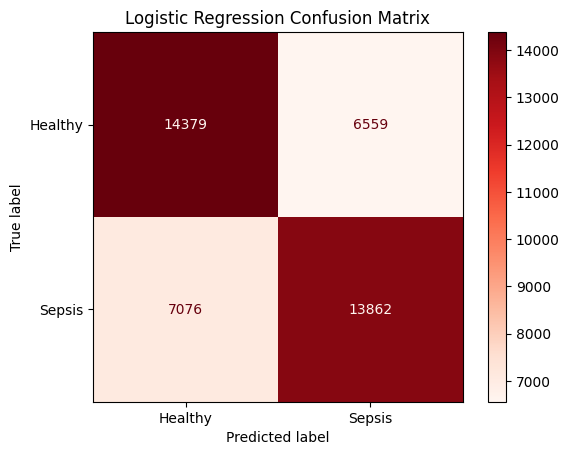

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

logit_model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)

# FIT the model 
logit_model.fit(X_train_const, y_train_res)

# Create a clean table of the weights
coeff_df = pd.DataFrame({
    'Feature': X_train_const.columns,
    'Coefficient': logit_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- Logistic Regression Coefficients ---")
print(coeff_df)
print(f"\nIntercept: {logit_model.intercept_[0]}")


# PREDICT
y_pred_logit = logit_model.predict(X_train_const)

# Get predictions from your trained Logistic Regression model
y_pred_logit = logit_model.predict(X_train_const)

# Create the confusion matrix
cm_logit = confusion_matrix(y_train_res, y_pred_logit)

# Print the formatted report (Precision, Recall, F1)
print("Logistic Regression Performance Report:")
print(classification_report(y_train_res, y_pred_logit, target_names=['Healthy', 'Sepsis']))

# Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logit, display_labels=['Healthy', 'Sepsis'])
disp.plot(cmap='Reds') # Using Reds to distinguish from the Blue QDA plot
plt.title('Logistic Regression Confusion Matrix')
plt.show()

True Positives (13,862): The model correctly identified these instances of sepsis. Because this number is high the model is clinically useful.
True Negatives (14,379): The model correctly identified healthy states, allowing doctors to focus elsewhere.
False Positives (6,559): These are patients who are healthy, but the model flagged them. Too many of these lead to "Alarm Fatigue," where nurses start ignoring the alerts. High False Positive Rate. 
False Negatives (7,076): A patient has sepsis, but the model says they are fine. 

Logistic Regression is much more "balanced." Notice that the Precision and Recall are almost the same (0.68 and 0.66). It’s not playing favorites.

Logistic Regression achieved a significantly higher Recall (0.66 vs 0.41).

# Quadratic Discriminant Analysis (QDA) 

Quadratic Discriminant Analysis (QDA) does not assume classes share the same covariances. Each class gets its own estimate of variance, the resulting decision boundary is curved (quadratic) rather than a straight line. It performs better than LDA when the spread of data differs significantly between groups. QDA needs to have a lot of data to find the covariances for each group. 

In [23]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd

# Initialize the QDA model
# QDA doesn't require hyperparameter tuning like 'C' in Logit, 
# making it straightforward to implement.
qda = QuadraticDiscriminantAnalysis()

# Set up Stratified 10-fold CV (Required by Step 2.2 & 2.6)
# Stratification ensures Sepsis cases are evenly spread across folds
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate using F1-score (Required by Step 3.2 for imbalanced data)
qda_cv_scores = cross_val_score(qda, X_train_res, y_train_res, 
                                cv=skf, scoring='f1')

print(f"Average QDA F1-Score (10-Fold CV): {qda_cv_scores.mean():.4f}")

# Fit the final model to extract insights
qda.fit(X_train_res, y_train_res)

Average QDA F1-Score (10-Fold CV): 0.4951


QuadraticDiscriminantAnalysis()

An F1 of 0.4951 indicates that while the model is catching many cases, it may still have a high number of False Positives (low precision) or is missing subtle cases (low recall).

In [24]:
# Fit the model to the training data
qda.fit(X_train_res, y_train_res)

# Extract the means for each class (0 = Healthy, 1 = Sepsis)
means_df = pd.DataFrame(qda.means_, columns=X_train.columns, index=['Healthy', 'Sepsis']).T
means_df['Difference'] = means_df['Sepsis'] - means_df['Healthy']

print("QDA Class Means (The 'Profile' of a Septic Patient):")
print(means_df.sort_values(by='Difference', ascending=False))

QDA Class Means (The 'Profile' of a Septic Patient):
                        Healthy    Sepsis  Difference
HR_peak               -0.035091  0.422187    0.457278
HR_mean               -0.029532  0.350364    0.379896
Temp_mean             -0.020151  0.324581    0.344732
Resp_peak             -0.026342  0.295986    0.322328
Resp_mean             -0.024064  0.283148    0.307212
BUN_mean              -0.024883  0.226057    0.250940
Bilirubin_direct_mean -0.020849  0.223754    0.244603
Bilirubin_total_mean  -0.021216  0.213518    0.234734
Lactate_peak          -0.022934  0.210899    0.233833
WBC_mean              -0.016881  0.160341    0.177222
Fibrinogen_mean       -0.010892  0.097146    0.108038
AST_mean              -0.010406  0.089896    0.100302
Gender                -0.005008  0.095194    0.100202
Glucose_mean          -0.010165  0.082843    0.093008
FiO2_mean             -0.007352  0.084381    0.091733
O2Sat_mean            -0.004103  0.084085    0.088187
pH_mean               -0.0029

## QDA Precision Testing 

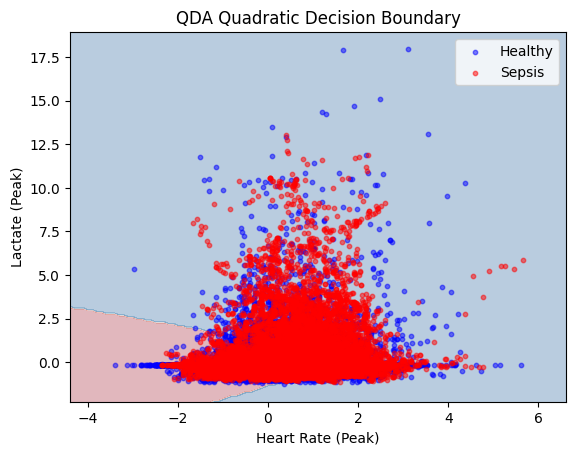

In [26]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 1. Pick the two most important features for visualization
features_to_plot = ['HR_peak', 'Lactate_peak']
X_vis = X_train_res[features_to_plot].values
y_vis = y_train_res.values

# 2. Fit QDA on just these two features
qda_vis = QuadraticDiscriminantAnalysis()
qda_vis.fit(X_vis, y_vis)

# 3. Create a mesh grid to plot the decision boundary
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = qda_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_vis[y_vis==0, 0], X_vis[y_vis==0, 1], c='blue', label='Healthy', alpha=0.5, s=10)
plt.scatter(X_vis[y_vis==1, 0], X_vis[y_vis==1, 1], c='red', label='Sepsis', alpha=0.5, s=10)
plt.xlabel('Heart Rate (Peak)')
plt.ylabel('Lactate (Peak)')
plt.title('QDA Quadratic Decision Boundary')
plt.legend()
plt.savefig('qda_decision_boundary.png')

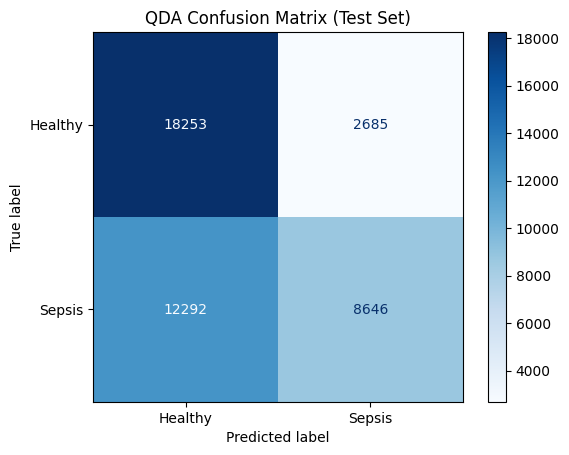

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from your full QDA model
y_pred = qda.predict(X_train_res)

cm = confusion_matrix(y_train_res, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Sepsis'])

disp.plot(cmap='Blues')
plt.title('QDA Confusion Matrix (Test Set)')
plt.savefig('qda_confusion_matrix.png')

True Negatives (18,253): The model correctly identified 18,253 healthy patient-time observations.
True Positives (8,646): The model successfully detected sepsis in 8,646 instances.
False Positives (2,685): These are "false alarms," where the model predicted sepsis for a healthy observation.
False Negatives (12,292): This is the most critical area for your report. The model missed 12,292 sepsis cases, classifying them as healthy.

Sensitivity 
The matrix shows a high number of False Negatives (12,292) compared to True Positives (8,646). In clinical sepsis detection, missing a case (False Negative) is generally considered more dangerous than a false alarm (False Positive). While QDA captures non-linear relationships, it currently struggles with high sensitivity in this imbalanced dataset.

While the QDA model demonstrates a respectable Precision of 76.3%, suggesting that its positive predictions are reliable, it suffers from a low Recall of 41.3%. In a clinical ICU setting, a model that misses nearly 60% of septic cases would be considered high-risk. This performance gap highlights the 'Sepsis Trade-off': the model is conservative to avoid false alarms, but as a result, it fails to identify many patients in the early stages of the condition. To improve this, we might consider adjusting the classification threshold to favor Recall over Precision.